In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv('../datasets/weight-height.csv')

In [71]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [73]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\3366809846.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

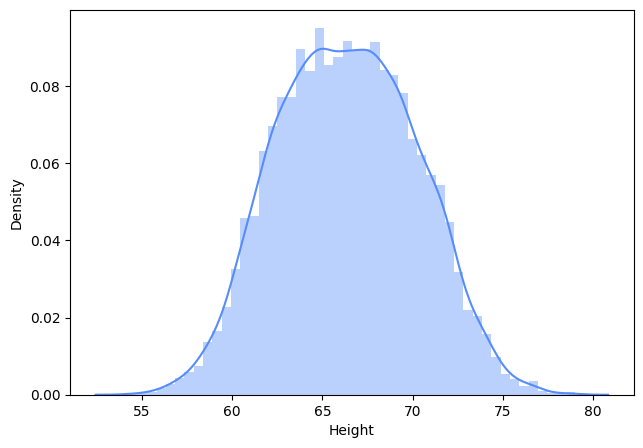

In [74]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

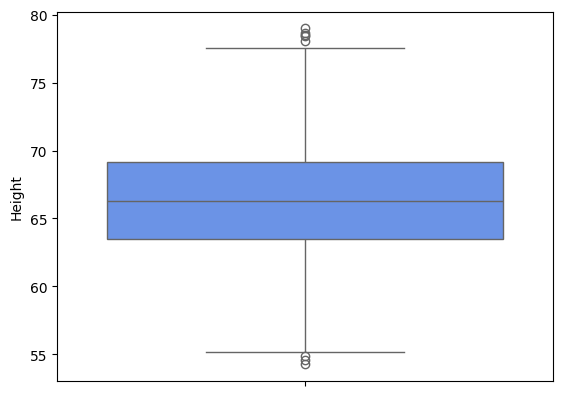

In [75]:
sns.boxplot(df['Height'])

In [76]:
# Finding the boundary values
upper_limit  = df['Height'].quantile(0.99)
lower_limit  = df['Height'].quantile(0.01)

In [77]:
print("Highest allowed", upper_limit)
print("Lowest allowed", lower_limit)

Highest allowed 74.7857900583366
Lowest allowed 58.13441158671655


In [78]:
# Finding the outliers
outliers = df[(df['Height'] >= lower_limit) & (df['Height'] <= upper_limit)]


In [79]:
outliers, outliers.shape

(      Gender     Height      Weight
 0       Male  73.847017  241.893563
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [9800 rows x 3 columns],
 (9800, 3))

In [80]:
# Trimming
df_no_outliers = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]
df_no_outliers, df_no_outliers.shape

(      Gender     Height      Weight
 0       Male  73.847017  241.893563
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [9800 rows x 3 columns],
 (9800, 3))

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\149831029.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


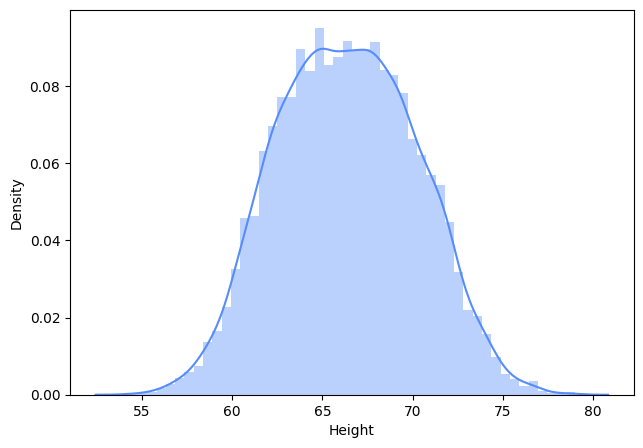

In [81]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Height'])
plt.show()


C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\2896722417.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_no_outliers['Height'])


<Axes: xlabel='Height', ylabel='Density'>

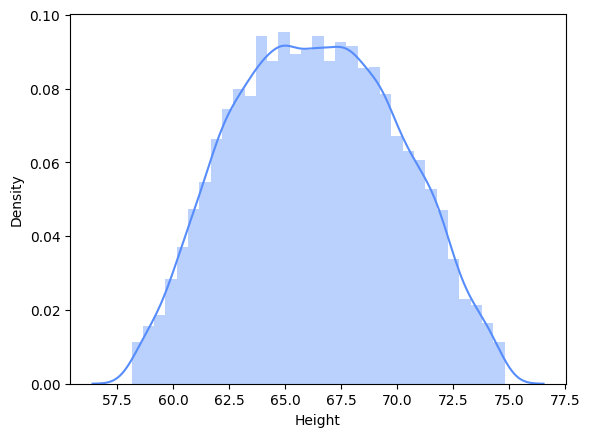

In [82]:
sns.distplot(df_no_outliers['Height'])
# sns.boxplot(df_no_outliers['Height'])

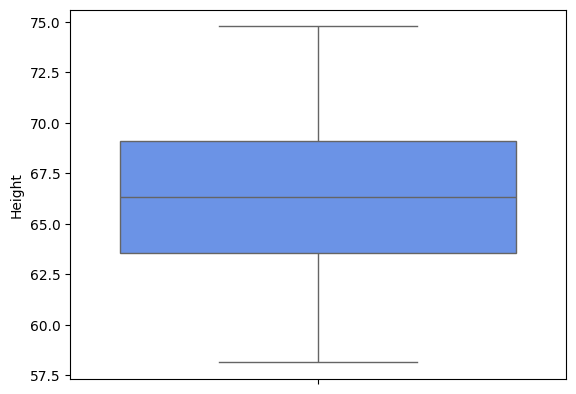

In [83]:
sns.boxplot(df_no_outliers['Height'])
plt.show()

In [84]:
# Capping --> Winsorization

df_capped = df.copy()
df_capped['Height'] = np.where(df_capped['Height'] > upper_limit, upper_limit, np.where(df_capped['Height'] < lower_limit, lower_limit, df_capped['Height']))

In [85]:
df_capped, df_capped.shape

(      Gender     Height      Weight
 0       Male  73.847017  241.893563
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [10000 rows x 3 columns],
 (10000, 3))

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\1870181659.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_capped['Height'])


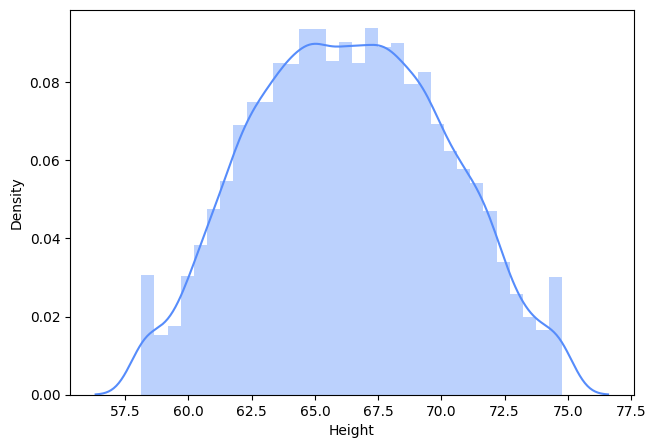

In [86]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df_capped['Height'])
plt.show()

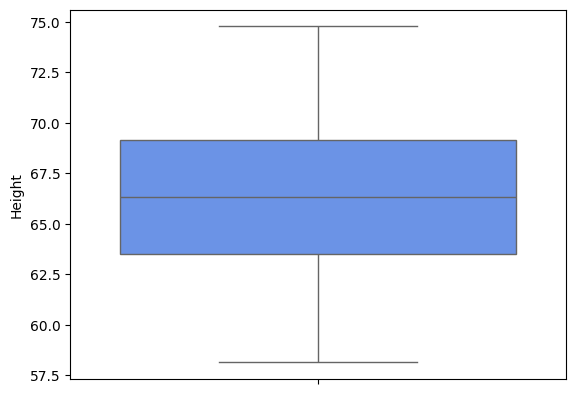

In [87]:
sns.boxplot(df_capped['Height'])
plt.show()

In [88]:
df['Weight'].describe()

count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989699
Name: Weight, dtype: float64

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\2027434227.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

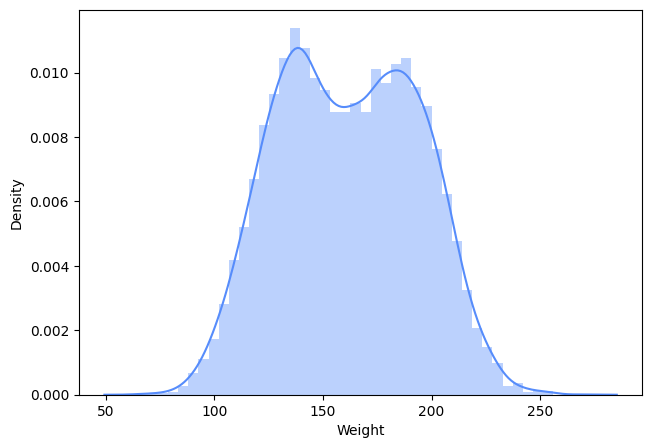

In [89]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Weight'])

<Axes: ylabel='Weight'>

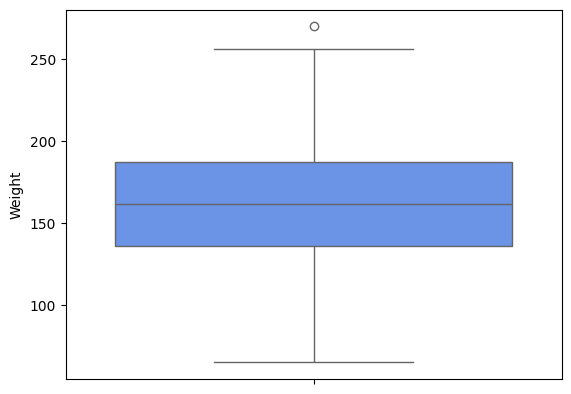

In [90]:
sns.boxplot(df['Weight'])

In [91]:
upper_limit = df['Weight'].quantile(0.99)
lower_limit = df['Weight'].quantile(0.01)

In [92]:
print("Highest allowed", upper_limit)
print("Lowest allowed", lower_limit)

Highest allowed 227.43736983602577
Lowest allowed 97.03287365980914


In [93]:
outliers = df[(df['Weight'] >= lower_limit) & (df['Weight'] <= upper_limit)]

In [94]:
outliers, outliers.shape

(      Gender     Height      Weight
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 5       Male  67.253016  152.212156
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [9800 rows x 3 columns],
 (9800, 3))

In [95]:
df_no_outliers = df[(df['Weight'] <= upper_limit) & (df['Weight'] >= lower_limit)]
df_no_outliers, df_no_outliers.shape

(      Gender     Height      Weight
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 5       Male  67.253016  152.212156
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [9800 rows x 3 columns],
 (9800, 3))

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\4150165515.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


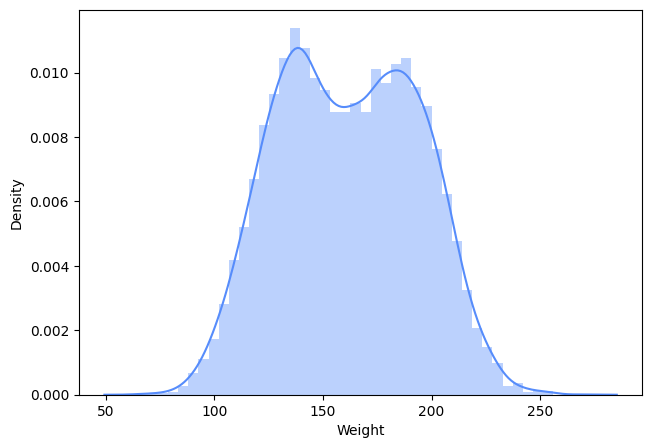

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\4150165515.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_no_outliers['Weight'])


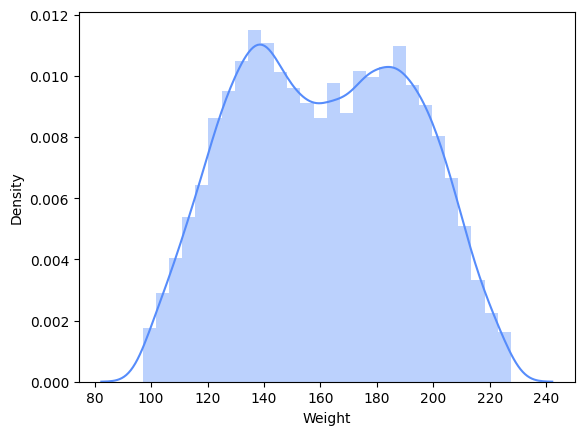

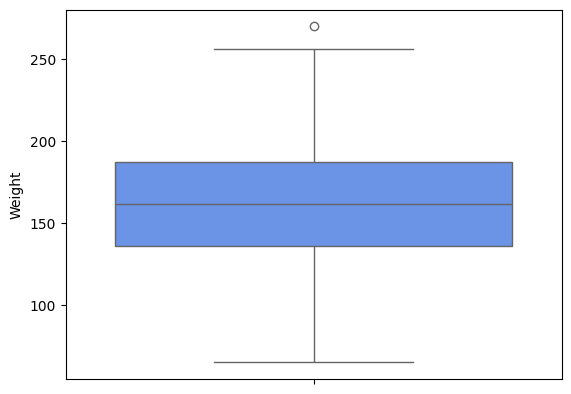

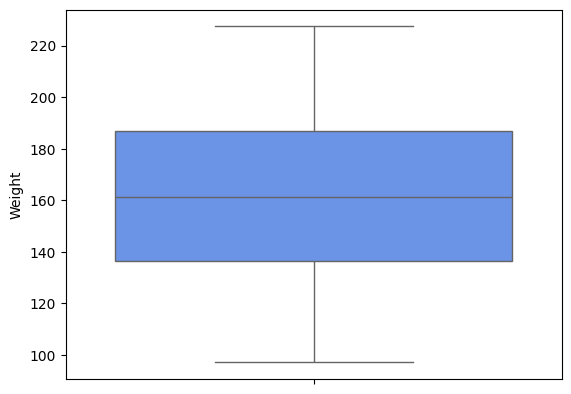

In [96]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Weight'])
plt.show()
sns.distplot(df_no_outliers['Weight'])
plt.show()
sns.boxplot(df['Weight'])
plt.show()
sns.boxplot(df_no_outliers['Weight'])
plt.show()

In [97]:
df_capped = df.copy()
df_capped['Weight'] = np.where(df_capped['Weight'] > upper_limit, upper_limit, np.where(df_capped['Weight'] < lower_limit, lower_limit, df_capped['Weight']))

In [98]:
df_capped, df_capped.shape

(      Gender     Height      Weight
 0       Male  73.847017  227.437370
 1       Male  68.781904  162.310473
 2       Male  74.110105  212.740856
 3       Male  71.730978  220.042470
 4       Male  69.881796  206.349801
 ...      ...        ...         ...
 9995  Female  66.172652  136.777454
 9996  Female  67.067155  170.867906
 9997  Female  63.867992  128.475319
 9998  Female  69.034243  163.852461
 9999  Female  61.944246  113.649103
 
 [10000 rows x 3 columns],
 (10000, 3))

C:\Users\manoj\AppData\Local\Temp\ipykernel_41992\3360433341.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_capped['Weight'])


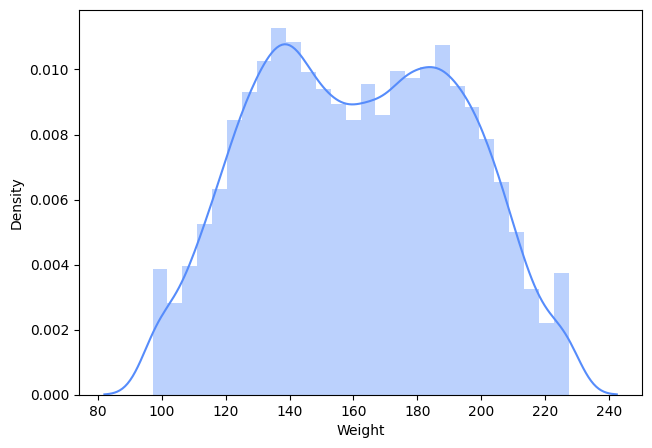

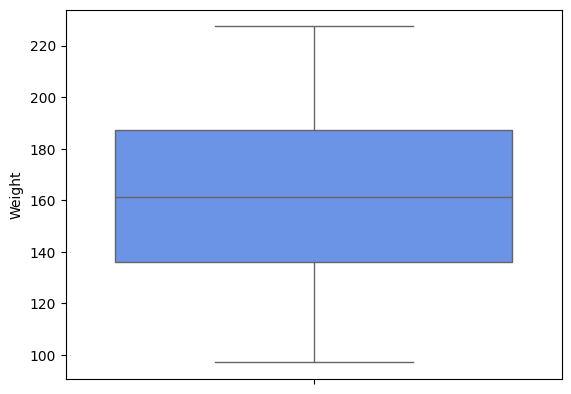

In [99]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df_capped['Weight'])
plt.show()
sns.boxplot(df_capped['Weight'])
plt.show()